# Hướng dẫn Hồi quy: Linear · Ridge · Lasso + Kiểm định thống kê

| Phần | Nội dung | Công cụ |
|---|---|---|
| 1 | Hồi quy tuyến tính (Linear Regression) | `sklearn`, `matplotlib` |
| 2 | Regularization — Ridge (L2) | `Ridge` |
| 3 | Regularization — Lasso (L1) | `Lasso` |
| 4 | Kiểm định thống kê (t-test, p-value, CI) | `statsmodels`, `scipy.stats` |

**Luồng tư duy:**
```
Dữ liệu → Mô hình → Đánh giá kỹ thuật (R², RMSE) → Đánh giá thống kê (t-test, p-value)
```

---
# PHẦN 1: Hồi quy tuyến tính (Linear Regression)

## Bước 1 — Đặt bài toán

Cho $N$ cặp quan sát $(x_i, y_i)$. Ta muốn tìm đường thẳng:
$$\hat{y} = \beta_0 + \beta_1 x$$

sao cho đường đó **gần nhất** với toàn bộ dữ liệu — tức là tối thiểu hóa tổng bình phương sai số:
$$SSE(\beta_0, \beta_1) = \sum_{i=1}^{N} (y_i - \beta_0 - \beta_1 x_i)^2$$

## Bước 2 — Suy luận toán học (điều kiện tối ưu)

Lấy đạo hàm riêng theo $\beta_0$ và $\beta_1$, đặt bằng 0:

$$\frac{\partial SSE}{\partial \beta_0} = -2\sum_{i=1}^{N}(y_i - \beta_0 - \beta_1 x_i) = 0$$

$$\frac{\partial SSE}{\partial \beta_1} = -2\sum_{i=1}^{N} x_i(y_i - \beta_0 - \beta_1 x_i) = 0$$

Từ phương trình đầu: $\quad N\beta_0 + \beta_1 \sum x_i = \sum y_i \quad \Rightarrow \quad \beta_0 = \bar{y} - \beta_1\bar{x}$

Thay vào phương trình thứ hai và rút gọn:

$$\boxed{\beta_1 = \frac{\sum_{i=1}^{N}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{N}(x_i - \bar{x})^2}, \qquad \beta_0 = \bar{y} - \beta_1\bar{x}}$$

Đây là **nghiệm đóng** (closed-form solution) — tính được trực tiếp, không cần lặp.

=== Tính tay (closed-form) ===
x_bar = 5.0000,  y_bar = 19.5046
beta1 = sum[(xi-x̄)(yi-ȳ)] / sum[(xi-x̄)²] = 3.0378  (thực: 3.0)
beta0 = ȳ - β₁·x̄              = 4.3154  (thực: 5.0)
SSE   = 1157.8237


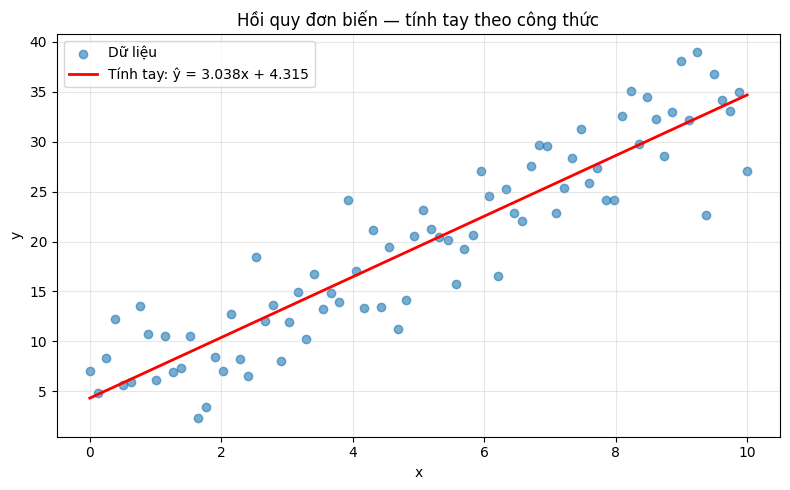

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Tạo dữ liệu: y = 3x + 5 + noise (biết trước nghiệm thực)
np.random.seed(42)
x = np.linspace(0, 10, 80)
y = 3 * x + 5 + np.random.normal(0, 4, 80)

# ── Tính tay theo công thức suy luận ──────────────────────────────
x_bar = x.mean()
y_bar = y.mean()

beta1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar)**2)
beta0 = y_bar - beta1 * x_bar

print('=== Tính tay (closed-form) ===')
print(f'x_bar = {x_bar:.4f},  y_bar = {y_bar:.4f}')
print(f'beta1 = sum[(xi-x̄)(yi-ȳ)] / sum[(xi-x̄)²] = {beta1:.4f}  (thực: 3.0)')
print(f'beta0 = ȳ - β₁·x̄              = {beta0:.4f}  (thực: 5.0)')

y_pred_manual = beta0 + beta1 * x
sse = np.sum((y - y_pred_manual)**2)
print(f'SSE   = {sse:.4f}')

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label='Dữ liệu')
plt.plot(x, y_pred_manual, color='red', linewidth=2,
         label=f'Tính tay: ŷ = {beta1:.3f}x + {beta0:.3f}')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Hồi quy đơn biến — tính tay theo công thức')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Bước 3 — Tổng quát hóa: Dạng ma trận (Normal Equation)

Với $p$ thuộc tính, viết lại mô hình dưới dạng ma trận:

$$X = \begin{bmatrix} 1 & x_{11} & \cdots & x_{1p} \\ 1 & x_{21} & \cdots & x_{2p} \\ \vdots & & \ddots & \vdots \\ 1 & x_{N1} & \cdots & x_{Np} \end{bmatrix}, \quad \beta = \begin{bmatrix}\beta_0 \\ \beta_1 \\ \vdots \\ \beta_p\end{bmatrix}, \quad y = \begin{bmatrix}y_1 \\ y_2 \\ \vdots \\ y_N\end{bmatrix}$$

Hàm mục tiêu: $SSE = \|y - X\beta\|^2 = (y - X\beta)^T(y - X\beta)$

Lấy đạo hàm theo vector $\beta$, đặt bằng 0:
$$\frac{\partial SSE}{\partial \beta} = -2X^T(y - X\beta) = 0 \quad \Rightarrow \quad X^TX\beta = X^Ty$$

$$\boxed{\hat{\beta} = (X^TX)^{-1}X^Ty} \quad \text{(Normal Equation)}$$

Công thức đơn biến ở trên chỉ là **trường hợp đặc biệt** của phương trình này.

In [ ]:
# ── Cài đặt Normal Equation bằng numpy thuần ─────────────────────
X_mat = np.column_stack([np.ones(len(x)), x])   # Thêm cột 1 cho β₀

# β̂ = (XᵀX)⁻¹ Xᵀy
XtX     = X_mat.T @ X_mat
Xty     = X_mat.T @ y
beta_ne = np.linalg.inv(XtX) @ Xty              # Normal Equation

print('=== Normal Equation: β̂ = (XᵀX)⁻¹ Xᵀy ===')
print(f'XᵀX =\n{XtX}')
print(f'\nXᵀy = {Xty}')
print(f'\nbeta_ne = {beta_ne}')
print(f'  β₀ = {beta_ne[0]:.6f}')
print(f'  β₁ = {beta_ne[1]:.6f}')

# Kiểm tra: kết quả phải khớp với tính tay đơn biến ở trên
print(f'\nKiểm tra khớp với tính tay:')
print(f'  β₀ tay = {beta0:.6f},  normal eq = {beta_ne[0]:.6f},  chênh lệch = {abs(beta0-beta_ne[0]):.2e}')
print(f'  β₁ tay = {beta1:.6f},  normal eq = {beta_ne[1]:.6f},  chênh lệch = {abs(beta1-beta_ne[1]):.2e}')

=== Normal Equation: β̂ = (XᵀX)⁻¹ Xᵀy ===
XᵀX =
[[  80.         400.       ]
 [ 400.        2683.5443038]]

Xᵀy = [1560.37115148 9878.3533049 ]

beta_ne = [4.31544437 3.037839  ]
  β₀ = 4.315444
  β₁ = 3.037839

Kiểm tra khớp với tính tay:
  β₀ tay = 4.315444,  normal eq = 4.315444,  chênh lệch = 1.07e-14
  β₁ tay = 3.037839,  normal eq = 3.037839,  chênh lệch = 0.00e+00


## Bước 4 — Sklearn `LinearRegression` làm gì bên trong?

`sklearn` cũng giải cùng Normal Equation đó — nhưng dùng **QR decomposition** hoặc **SVD** thay vì tính $(X^TX)^{-1}$ trực tiếp (ổn định số học hơn khi ma trận gần suy biến).

Kết quả phải **khớp hoàn toàn** với tính tay.

=== sklearn LinearRegression ===
β₀ = 4.315444
β₁ = 3.037839

So sánh 3 cách:
                     β₀           β₁
  Tính tay     4.315444     3.037839
 Normal Eq     4.315444     3.037839
   sklearn     4.315444     3.037839

=> Ba cách cho kết quả GIỐNG HỆT NHAU (sai khác do floating-point < 1e-10)


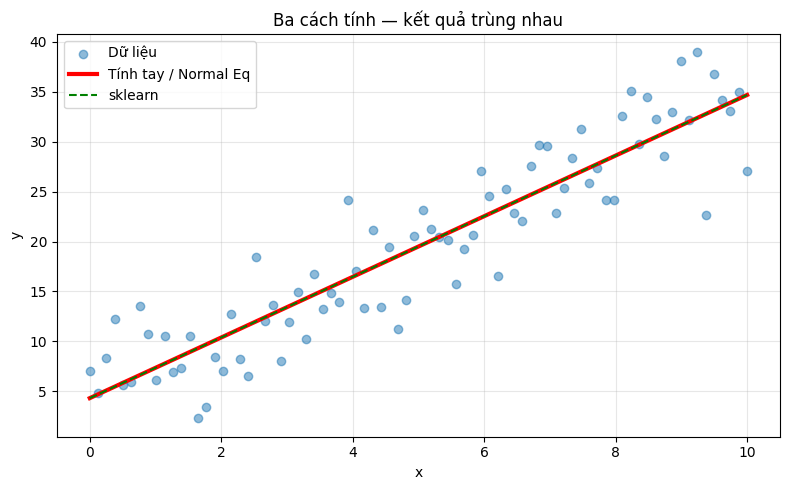

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)

print('=== sklearn LinearRegression ===')
print(f'β₀ = {model.intercept_:.6f}')
print(f'β₁ = {model.coef_[0]:.6f}')

print(f'\nSo sánh 3 cách:')
print(f'{"":>10} {"β₀":>12} {"β₁":>12}')
print(f'{"Tính tay":>10} {beta0:>12.6f} {beta1:>12.6f}')
print(f'{"Normal Eq":>10} {beta_ne[0]:>12.6f} {beta_ne[1]:>12.6f}')
print(f'{"sklearn":>10} {model.intercept_:>12.6f} {model.coef_[0]:>12.6f}')
print(f'\n=> Ba cách cho kết quả GIỐNG HỆT NHAU (sai khác do floating-point < 1e-10)')

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5, label='Dữ liệu', zorder=2)
plt.plot(x, y_pred_manual,   color='red',    linewidth=3, linestyle='-',  label='Tính tay / Normal Eq')
plt.plot(x, model.predict(X), color='green', linewidth=1.5, linestyle='--', label='sklearn')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Ba cách tính — kết quả trùng nhau')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 1.2 Các chỉ số đánh giá

| Chỉ số | Công thức | Tốt khi |
|---|---|---|
| **R²** | $1 - SSE/SST$ | Gần 1 |
| **MSE** | $\frac{1}{N}\sum(y_i-\hat{y}_i)^2$ | Nhỏ |
| **RMSE** | $\sqrt{MSE}$ — cùng đơn vị $y$ | Nhỏ |
| **MAE** | $\frac{1}{N}\sum|y_i-\hat{y}_i|$ — bền với outlier | Nhỏ |

In [ ]:
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
mse  = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y, y_pred)

print(f'R2   = {r2:.4f}  -> mo hinh giai thich {r2*100:.1f}% phuong sai cua y')
print(f'MSE  = {mse:.4f}')
print(f'RMSE = {rmse:.4f}  -> sai so trung binh ~ {rmse:.2f} don vi y')
print(f'MAE  = {mae:.4f}')

R2   = 0.8449  -> mo hinh giai thich 84.5% phuong sai cua y
MSE  = 14.4728
RMSE = 3.8043  -> sai so trung binh ~ 3.80 don vi y
MAE  = 3.0315


## 1.3 Phân tích phần dư (Residual Analysis)

Phần dư $e_i = y_i - \hat{y}_i$ phải:
- **Ngẫu nhiên** (không có cấu trúc) khi vẽ theo $\hat{y}$ → mô hình đã nắm bắt đủ thông tin
- **Phân phối chuẩn** → giả định OLS được thỏa
- **Trung bình ≈ 0** → không lệch hệ thống

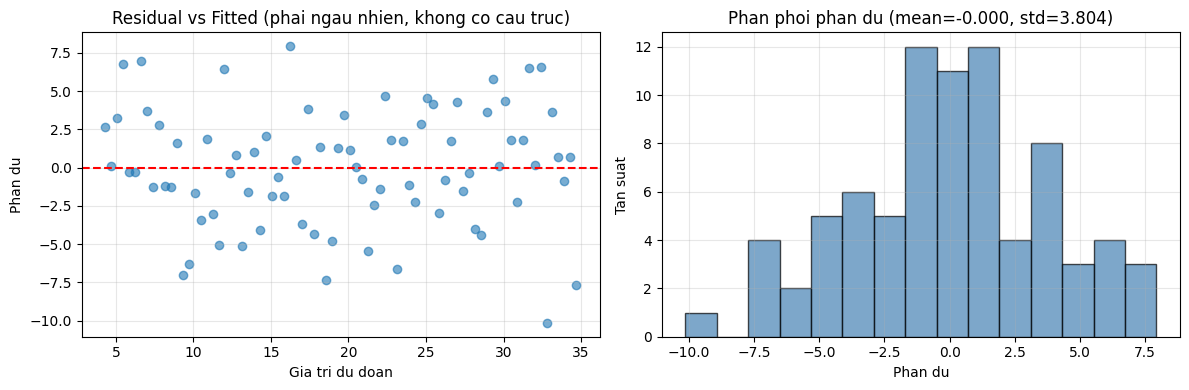

In [ ]:
residuals = y - y_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Gia tri du doan'); axes[0].set_ylabel('Phan du')
axes[0].set_title('Residual vs Fitted (phai ngau nhien, khong co cau truc)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Phan du'); axes[1].set_ylabel('Tan suat')
axes[1].set_title(f'Phan phoi phan du (mean={residuals.mean():.3f}, std={residuals.std():.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 1.4 Hồi quy đa biến — Diabetes Dataset

442 bệnh nhân, 10 thuộc tính (tuổi, BMI, huyết áp...), nhãn = mức độ tiến triển bệnh sau 1 năm.

In [ ]:
data = load_diabetes()
X_d, y_d = data.data, data.target
feat_names = data.feature_names

X_tr, X_te, y_tr, y_te = train_test_split(X_d, y_d, test_size=0.2, random_state=42)
lr = LinearRegression().fit(X_tr, y_tr)

print(f'R2 train: {r2_score(y_tr, lr.predict(X_tr)):.4f}')
print(f'R2 test : {r2_score(y_te, lr.predict(X_te)):.4f}')
print(f'RMSE test: {np.sqrt(mean_squared_error(y_te, lr.predict(X_te))):.2f}\n')

print('He so hoi quy:')
for name, coef in zip(feat_names, lr.coef_):
    print(f'  {name:<6}: {coef:>8.3f}')
print(f'  intercept: {lr.intercept_:.3f}')

R2 train: 0.5279
R2 test : 0.4526
RMSE test: 53.85

He so hoi quy:
  age   :   37.904
  sex   : -241.964
  bmi   :  542.429
  bp    :  347.704
  s1    : -931.489
  s2    :  518.062
  s3    :  163.420
  s4    :  275.318
  s5    :  736.199
  s6    :   48.671
  intercept: 151.346


/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


---
# PHẦN 2: Ridge Regression (L2 Regularization)

## Vấn đề: Overfitting trong hồi quy

Khi dùng nhiều đặc trưng (đặc biệt polynomial), hệ số $\beta$ có thể rất lớn → khớp sát train nhưng test tệ.

## Giải pháp: Ridge thêm phạt L2
$$\min_{\beta} \underbrace{\sum(y_i - \hat{y}_i)^2}_{\text{sai so}} + \underbrace{\alpha \sum_{j=1}^{p} \beta_j^2}_{\text{phat L2}}$$

| $\alpha$ | Kết quả |
|---|---|
| 0 | Giống Linear Regression |
| Lớn | Hệ số co về 0, mô hình đơn giản hơn |

Ridge **không** đưa hệ số về đúng 0 — chỉ làm nhỏ chúng.

/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-p

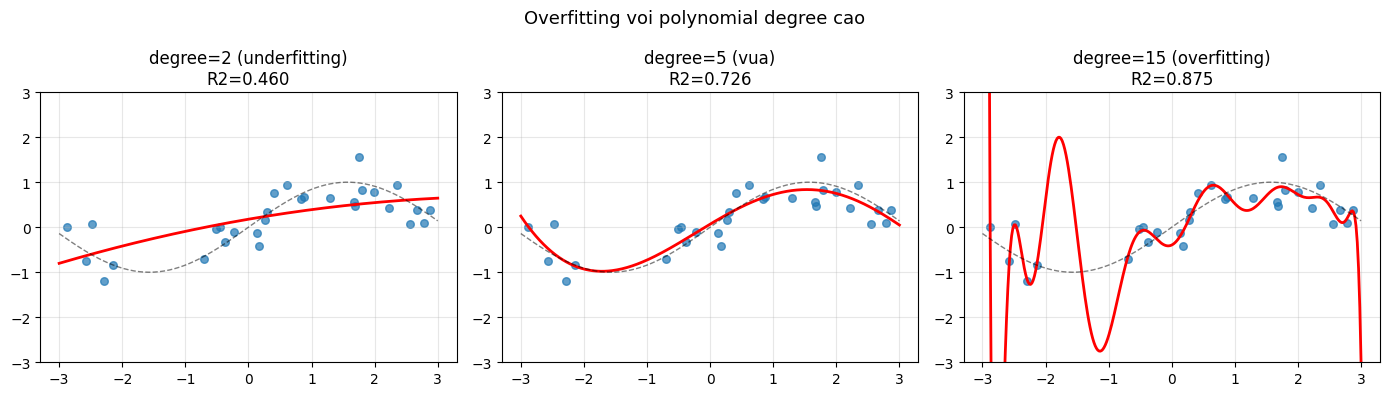

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# Dữ liệu: y = sin(x) + noise
np.random.seed(0)
x_p = np.sort(np.random.uniform(-3, 3, 30))
y_p = np.sin(x_p) + np.random.normal(0, 0.3, 30)
X_p = x_p.reshape(-1, 1)
xx_p = np.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, deg, title in zip(axes,
                          [2, 5, 15],
                          ['degree=2 (underfitting)', 'degree=5 (vua)', 'degree=15 (overfitting)']):
    pipe = Pipeline([('poly', PolynomialFeatures(degree=deg)),
                     ('scaler', StandardScaler()),
                     ('lr', LinearRegression())])
    pipe.fit(X_p, y_p)
    r2 = r2_score(y_p, pipe.predict(X_p))
    ax.scatter(x_p, y_p, s=30, alpha=0.7)
    ax.plot(xx_p, pipe.predict(xx_p), color='red', linewidth=2)
    ax.plot(xx_p, np.sin(xx_p), 'k--', linewidth=1, alpha=0.5)
    ax.set_title(f'{title}\nR2={r2:.3f}'); ax.set_ylim(-3, 3); ax.grid(True, alpha=0.3)

plt.suptitle('Overfitting voi polynomial degree cao', fontsize=13)
plt.tight_layout(); plt.show()

/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered

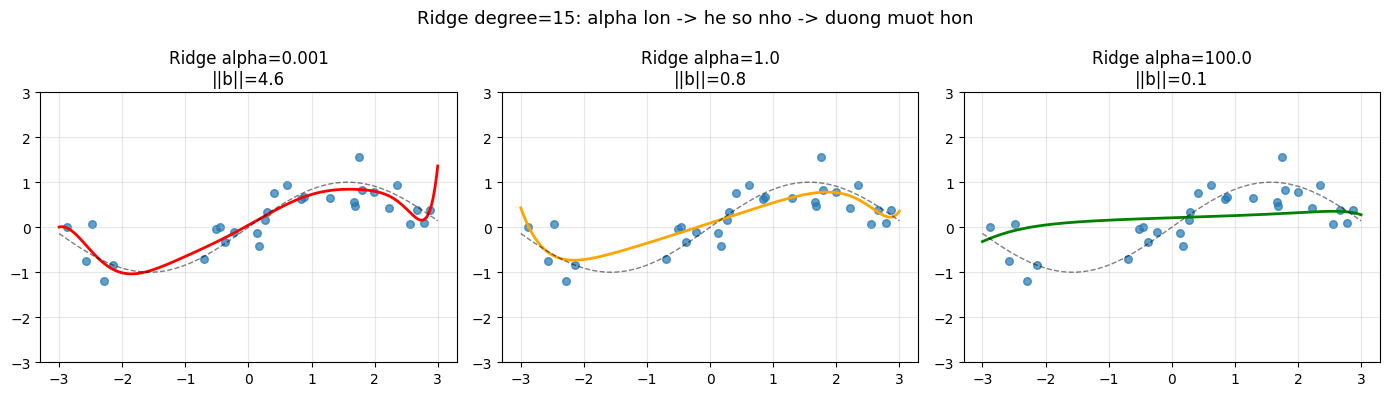

In [ ]:
# Ridge kiem soat overfitting
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, alpha, color in zip(axes, [0.001, 1.0, 100.0], ['red', 'orange', 'green']):
    pipe = Pipeline([('poly', PolynomialFeatures(degree=15)),
                     ('scaler', StandardScaler()),
                     ('ridge', Ridge(alpha=alpha))])
    pipe.fit(X_p, y_p)
    coef_norm = np.linalg.norm(pipe.named_steps['ridge'].coef_)
    ax.scatter(x_p, y_p, s=30, alpha=0.7)
    ax.plot(xx_p, pipe.predict(xx_p), color=color, linewidth=2)
    ax.plot(xx_p, np.sin(xx_p), 'k--', linewidth=1, alpha=0.5)
    ax.set_title(f'Ridge alpha={alpha}\n||b||={coef_norm:.1f}')
    ax.set_ylim(-3, 3); ax.grid(True, alpha=0.3)

plt.suptitle('Ridge degree=15: alpha lon -> he so nho -> duong muot hon', fontsize=13)
plt.tight_layout(); plt.show()

/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered

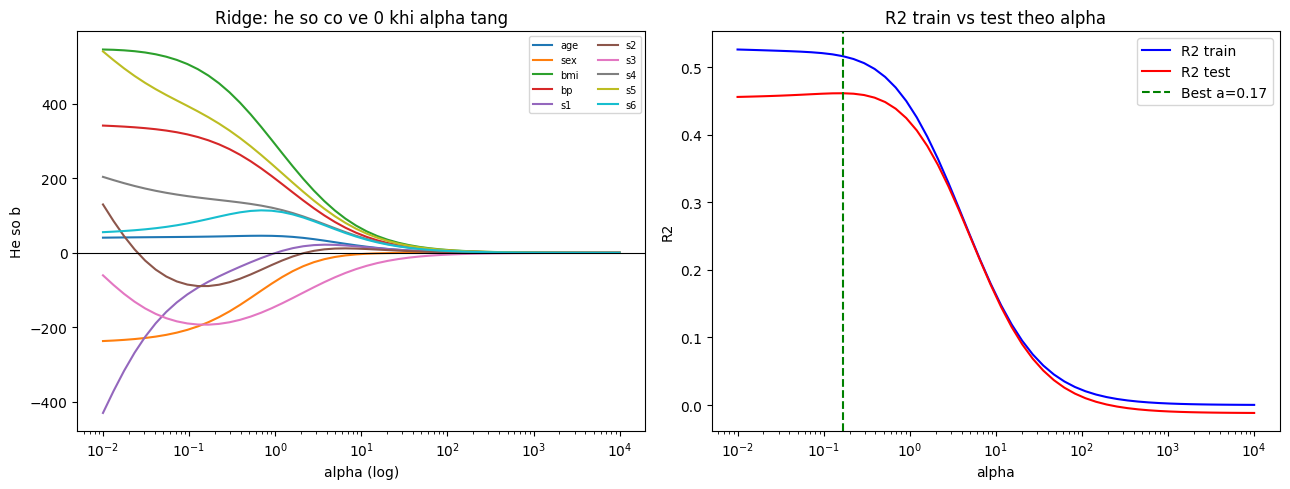

Alpha tot nhat (test R2 cao nhat): 0.1677


In [ ]:
# Anh huong cua alpha len he so va R2 — Diabetes
alphas = np.logspace(-2, 4, 50)
coefs, r2_trains, r2_tests = [], [], []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_tr, y_tr)
    coefs.append(ridge.coef_)
    r2_trains.append(r2_score(y_tr, ridge.predict(X_tr)))
    r2_tests.append(r2_score(y_te, ridge.predict(X_te)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for coef_path, name in zip(np.array(coefs).T, feat_names):
    axes[0].plot(alphas, coef_path, label=name)
axes[0].set_xscale('log'); axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xlabel('alpha (log)'); axes[0].set_ylabel('He so b')
axes[0].set_title('Ridge: he so co ve 0 khi alpha tang')
axes[0].legend(fontsize=7, ncol=2)

axes[1].plot(alphas, r2_trains, label='R2 train', color='blue')
axes[1].plot(alphas, r2_tests,  label='R2 test',  color='red')
best_a = alphas[np.argmax(r2_tests)]
axes[1].axvline(best_a, color='green', linestyle='--', label=f'Best a={best_a:.2f}')
axes[1].set_xscale('log'); axes[1].set_xlabel('alpha'); axes[1].set_ylabel('R2')
axes[1].set_title('R2 train vs test theo alpha'); axes[1].legend()

plt.tight_layout()
plt.savefig('ridge_alpha.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Alpha tot nhat (test R2 cao nhat): {best_a:.4f}')

---
# PHẦN 3: Lasso Regression (L1 Regularization)

## Công thức
$$\min_{\beta} \sum(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

## Ridge vs Lasso — Khác biệt cốt lõi

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | $\sum \beta_j^2$ | $\sum |\beta_j|$ |
| Hệ số | Co về 0, không triệt tiêu | **Đưa về đúng 0** |
| Dùng khi | Nhiều thuộc tính quan trọng | Muốn chọn lọc thuộc tính |
| Kết quả | Mô hình mượt | Mô hình thưa (sparse) |

**Tại sao Lasso triệt tiêu hệ số?** Penalty $|\beta|$ tạo góc nhọn trong không gian tối ưu → nghiệm chạm trục tọa độ → $\beta_j = 0$.

/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test

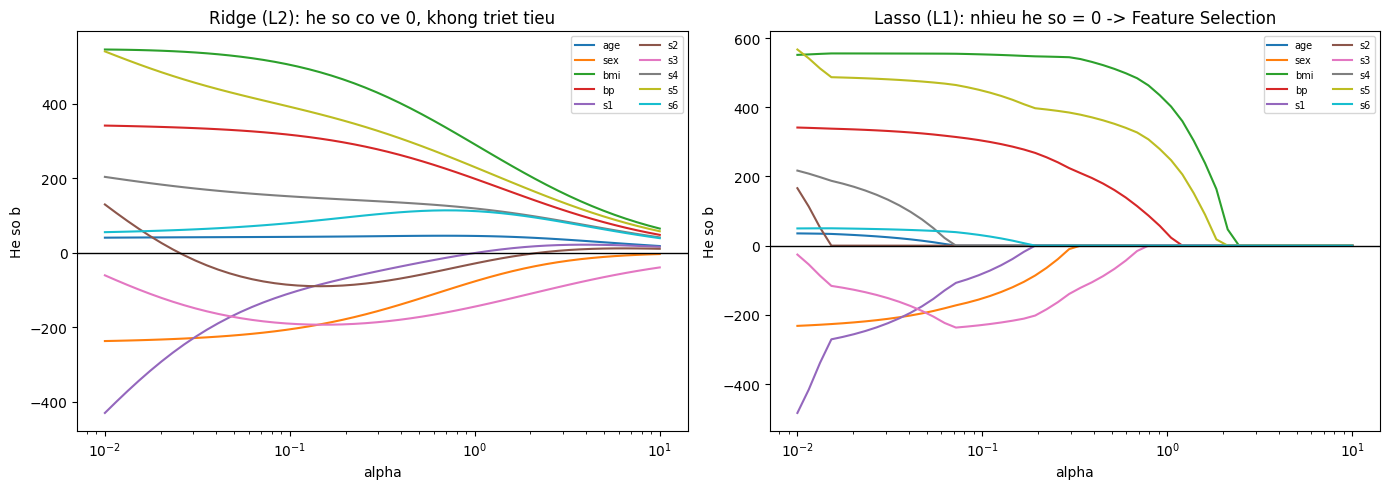

In [ ]:
alphas_l = np.logspace(-2, 1, 50)
lasso_coefs, ridge_coefs = [], []

for a in alphas_l:
    lasso_coefs.append(Lasso(alpha=a, max_iter=5000).fit(X_tr, y_tr).coef_)
    ridge_coefs.append(Ridge(alpha=a).fit(X_tr, y_tr).coef_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for coefs_arr, title, ax in [
    (ridge_coefs, 'Ridge (L2): he so co ve 0, khong triet tieu', axes[0]),
    (lasso_coefs, 'Lasso (L1): nhieu he so = 0 -> Feature Selection', axes[1])
]:
    for coef_path, name in zip(np.array(coefs_arr).T, feat_names):
        ax.plot(alphas_l, coef_path, label=name)
    ax.set_xscale('log'); ax.axhline(0, color='black', lw=1)
    ax.set_xlabel('alpha'); ax.set_ylabel('He so b')
    ax.set_title(title); ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('ridge_vs_lasso_coefs.png', dpi=120, bbox_inches='tight')
plt.show()

/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


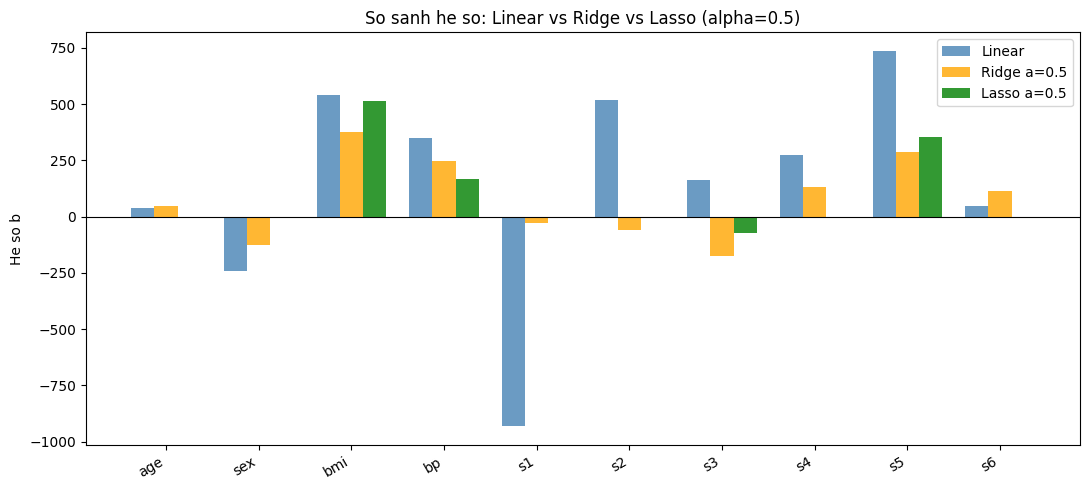

Lasso dua 6/10 he so ve 0
Thuoc tinh giu lai: ['bmi', 'bp', 's3', 's5']


In [ ]:
# So sanh he so tai alpha = 0.5
alpha_c = 0.5
ridge_c = Ridge(alpha=alpha_c).fit(X_tr, y_tr)
lasso_c = Lasso(alpha=alpha_c, max_iter=5000).fit(X_tr, y_tr)

x_pos = np.arange(len(feat_names))
w = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x_pos - w, lr.coef_,     w, label='Linear',          color='steelblue', alpha=0.8)
ax.bar(x_pos,     ridge_c.coef_, w, label=f'Ridge a={alpha_c}', color='orange',   alpha=0.8)
ax.bar(x_pos + w, lasso_c.coef_, w, label=f'Lasso a={alpha_c}', color='green',    alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(feat_names, rotation=30, ha='right')
ax.set_ylabel('He so b')
ax.set_title(f'So sanh he so: Linear vs Ridge vs Lasso (alpha={alpha_c})')
ax.legend()
plt.tight_layout()
plt.savefig('coef_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Lasso dua {sum(lasso_c.coef_ == 0)}/{len(feat_names)} he so ve 0')
kept = [feat_names[i] for i in range(len(feat_names)) if lasso_c.coef_[i] != 0]
print(f'Thuoc tinh giu lai: {kept}')

---
# PHẦN 4: Kiểm định thống kê — Đánh giá độ tin cậy mô hình

Chỉ số kỹ thuật (R², RMSE) cho biết mô hình **dự đoán tốt thế nào**.  
Kiểm định thống kê trả lời:
- Hệ số $\beta_j$ có **thực sự khác 0** không (hay chỉ do may mắn)?
- Mô hình A có **tốt hơn thực sự** mô hình B không?

## Khung tư duy kiểm định giả thuyết

| Bước | Nội dung |
|---|---|
| 1 | Đặt $H_0$ (null hypothesis) và $H_1$ (alternative) |
| 2 | Tính **test statistic** (t-value, F-value...) |
| 3 | Tính **p-value** = P(kết quả cực đoan hơn \| $H_0$ đúng) |
| 4 | p < 0.05 → **bác bỏ $H_0$** với mức ý nghĩa 5% |

## 4.1 t-test cho hệ số hồi quy (statsmodels OLS)

**Câu hỏi:** Thuộc tính $x_j$ có tác động thực sự lên $y$ không?

$$H_0: \beta_j = 0 \quad (\text{thuoc tinh khong co y nghia})$$

**t-statistic:**
$$t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$$

- $|t_j| > 2$ thường tương đương p < 0.05 với mẫu đủ lớn
- **p-value**: xác suất quan sát được $|t| \geq |t_j|$ nếu $H_0$ đúng

In [ ]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 5.3 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# pip install statsmodels  (neu chua co)
import statsmodels.api as sm

X_sm = sm.add_constant(X_d)  # Them cot hang so cho intercept
ols  = sm.OLS(y_d, X_sm).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Fri, 22 May 2026   Prob (F-statistic):           3.83e-62
Time:                        10:13:47   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.576     59.061      0.0

feature      coef  t_stat  p_value  significant
  const  152.1335 59.0614   0.0000         True
    age  -10.0099 -0.1675   0.8670        False
    sex -239.8156 -3.9171   0.0001         True
    bmi  519.8459  7.8133   0.0000         True
     bp  324.3846  4.9583   0.0000         True
     s1 -792.1756 -1.9012   0.0579        False
     s2  476.7390  1.4062   0.1604        False
     s3  101.0433  0.4754   0.6347        False
     s4  177.0632  1.0965   0.2735        False
     s5  751.2737  4.3704   0.0000         True
     s6   67.6267  1.0249   0.3060        False


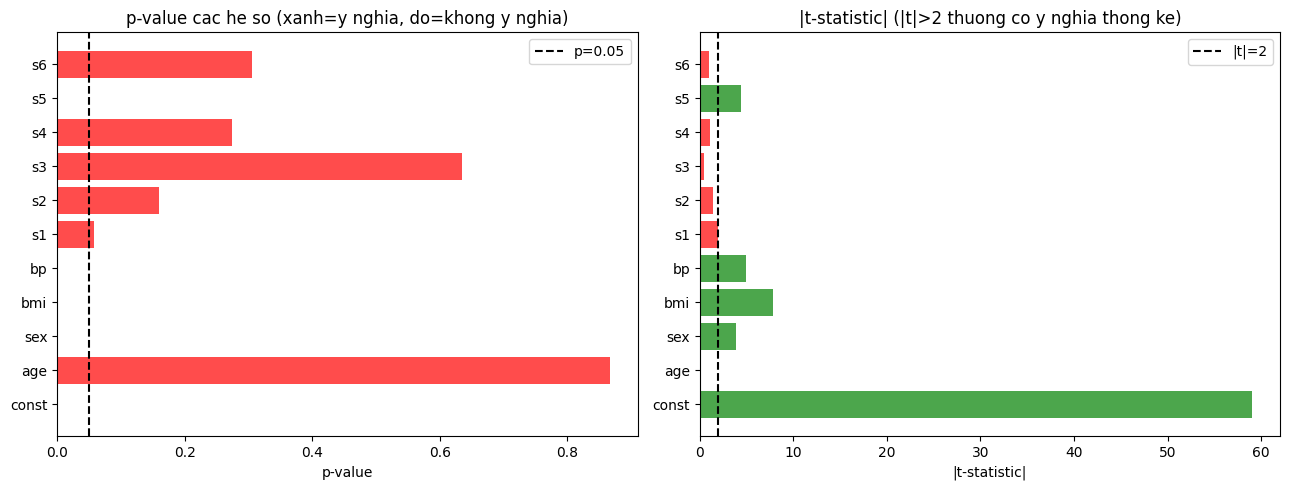

In [ ]:
# Trich xuat va truc quan hoa t-stat + p-value
df_res = pd.DataFrame({
    'feature'    : ['const'] + list(feat_names),
    'coef'       : ols.params,
    't_stat'     : ols.tvalues,
    'p_value'    : ols.pvalues,
    'significant': ols.pvalues < 0.05
})
print(df_res.to_string(index=False, float_format='{:.4f}'.format))

colors = ['green' if s else 'red' for s in df_res['significant']]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(df_res['feature'], df_res['p_value'], color=colors, alpha=0.7)
axes[0].axvline(0.05, color='black', linestyle='--', linewidth=1.5, label='p=0.05')
axes[0].set_xlabel('p-value')
axes[0].set_title('p-value cac he so (xanh=y nghia, do=khong y nghia)')
axes[0].legend()

axes[1].barh(df_res['feature'], np.abs(df_res['t_stat']), color=colors, alpha=0.7)
axes[1].axvline(2.0, color='black', linestyle='--', linewidth=1.5, label='|t|=2')
axes[1].set_xlabel('|t-statistic|')
axes[1].set_title('|t-statistic| (|t|>2 thuong co y nghia thong ke)')
axes[1].legend()

plt.tight_layout()
plt.savefig('tstat_pvalue.png', dpi=120, bbox_inches='tight')
plt.show()

## 4.2 Khoảng tin cậy (Confidence Interval) cho hệ số

$$CI_{95\%} = \hat{\beta}_j \pm t_{0.025,\, n-p-1} \cdot SE(\hat{\beta}_j)$$

- Khoảng **không chứa 0** → hệ số có ý nghĩa (tương đương p < 0.05)
- Khoảng càng **hẹp** → ước lượng càng chính xác (cần nhiều dữ liệu hơn)

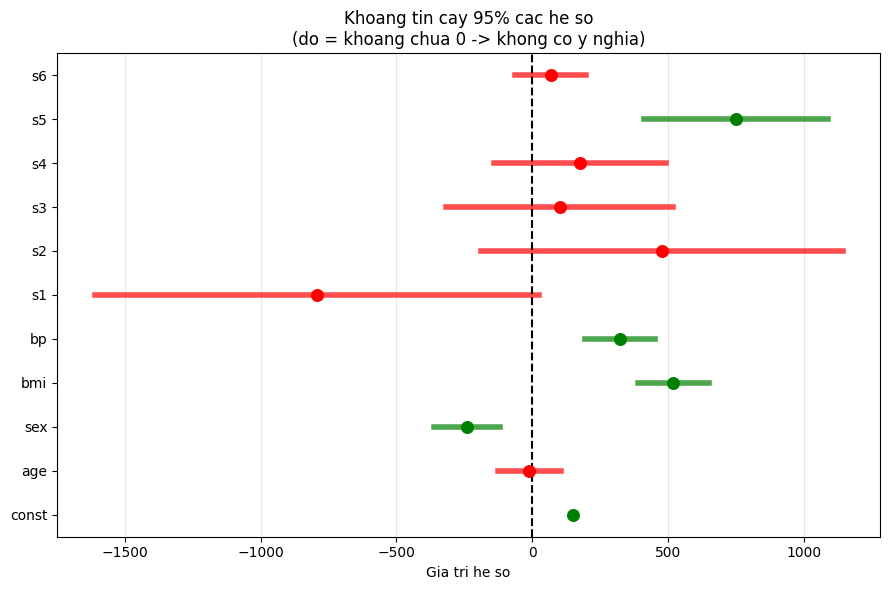

In [ ]:
import pandas as pd

ci_arr = ols.conf_int(alpha=0.05)
ci = pd.DataFrame(ci_arr, columns=['lower', 'upper'],
                  index=['const'] + list(feat_names))

fig, ax = plt.subplots(figsize=(9, 6))
for i, (feat, row) in enumerate(ci.iterrows()):
    coef_val = ols.params[i]
    color = 'green' if (row['lower'] > 0 or row['upper'] < 0) else 'red'
    ax.plot([row['lower'], row['upper']], [i, i], color=color, linewidth=4, alpha=0.7)
    ax.scatter(coef_val, i, color=color, s=70, zorder=5)

ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_yticks(range(len(ci))); ax.set_yticklabels(ci.index)
ax.set_xlabel('Gia tri he so')
ax.set_title('Khoang tin cay 95% cac he so\n(do = khoang chua 0 -> khong co y nghia)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('confidence_intervals.png', dpi=120, bbox_inches='tight')
plt.show()

## 4.3 Paired t-test — So sánh 2 mô hình

**Câu hỏi:** Mô hình A có tốt hơn thực sự mô hình B không, hay chỉ do may mắn?

**Cách làm:** Cross-validation → lấy nhiều giá trị error → dùng t-test so sánh.

$$H_0: \mu_{\text{error}_A} = \mu_{\text{error}_B}$$

**Paired** (`ttest_rel`): 2 mô hình test trên **cùng fold** → loại bỏ ảnh hưởng của dữ liệu.  
**Independent** (`ttest_ind`): 2 nhóm lấy mẫu **độc lập**.

In [ ]:
from scipy import stats

# Cross-validation 10 fold
cv_lr    = -cross_val_score(LinearRegression(),   X_d, y_d, cv=10, scoring='neg_root_mean_squared_error')
cv_ridge = -cross_val_score(Ridge(alpha=1.0),     X_d, y_d, cv=10, scoring='neg_root_mean_squared_error')
cv_lasso = -cross_val_score(Lasso(alpha=0.1, max_iter=5000), X_d, y_d, cv=10, scoring='neg_root_mean_squared_error')

print('RMSE tren 10 folds:')
print(f'  Linear: {cv_lr.mean():.3f} +- {cv_lr.std():.3f}')
print(f'  Ridge : {cv_ridge.mean():.3f} +- {cv_ridge.std():.3f}')
print(f'  Lasso : {cv_lasso.mean():.3f} +- {cv_lasso.std():.3f}')

RMSE tren 10 folds:
  Linear: 54.405 +- 6.366
  Ridge : 57.748 +- 5.454
  Lasso : 54.461 +- 5.880


/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test

In [ ]:
def paired_ttest(name_a, err_a, name_b, err_b):
    t, p = stats.ttest_rel(err_a, err_b)
    print(f'Paired t-test: {name_a} vs {name_b}')
    print(f'  H0: RMSE trung binh {name_a} = {name_b}')
    print(f'  t = {t:.4f},  p = {p:.4f}')
    if p < 0.05:
        better = name_b if err_b.mean() < err_a.mean() else name_a
        print(f'  => BAC BO H0 (p < 0.05): {better} tot hon co y nghia thong ke')
    else:
        print(f'  => KHONG bac bo H0 (p >= 0.05): chua du bang chung hai mo hinh khac nhau')
    print()

paired_ttest('Linear', cv_lr, 'Ridge', cv_ridge)
paired_ttest('Linear', cv_lr, 'Lasso', cv_lasso)
paired_ttest('Ridge',  cv_ridge, 'Lasso', cv_lasso)

Paired t-test: Linear vs Ridge
  H0: RMSE trung binh Linear = Ridge
  t = -2.6199,  p = 0.0278
  => BAC BO H0 (p < 0.05): Linear tot hon co y nghia thong ke

Paired t-test: Linear vs Lasso
  H0: RMSE trung binh Linear = Lasso
  t = -0.1359,  p = 0.8949
  => KHONG bac bo H0 (p >= 0.05): chua du bang chung hai mo hinh khac nhau

Paired t-test: Ridge vs Lasso
  H0: RMSE trung binh Ridge = Lasso
  t = 3.1694,  p = 0.0114
  => BAC BO H0 (p < 0.05): Lasso tot hon co y nghia thong ke



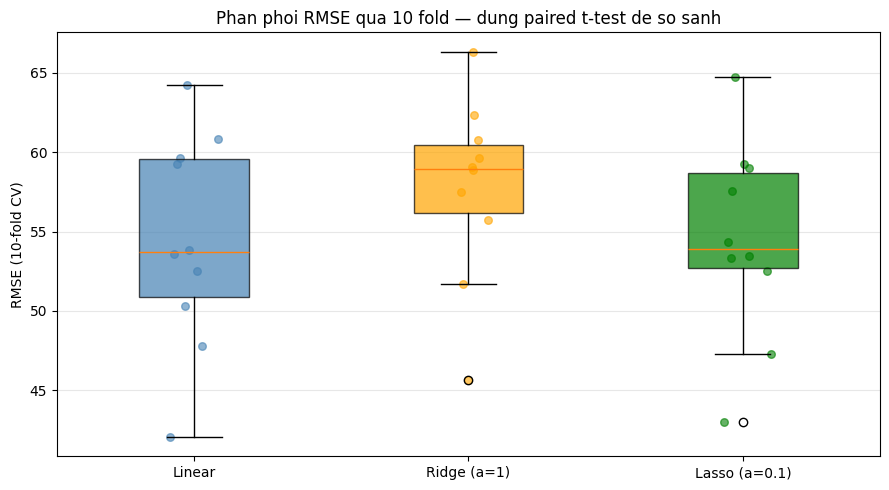

In [ ]:
# Truc quan hoa phan phoi RMSE qua cac fold
fig, ax = plt.subplots(figsize=(9, 5))
data_bp = [cv_lr, cv_ridge, cv_lasso]
labels  = ['Linear', 'Ridge (a=1)', 'Lasso (a=0.1)']
colors  = ['steelblue', 'orange', 'green']

bp = ax.boxplot(data_bp, positions=[1,2,3], patch_artist=True, widths=0.4)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
for pos, d, c in zip([1,2,3], data_bp, colors):
    ax.scatter(np.random.normal(pos, 0.05, len(d)), d, alpha=0.6, s=30, color=c)

ax.set_xticks([1,2,3]); ax.set_xticklabels(labels)
ax.set_ylabel('RMSE (10-fold CV)')
ax.set_title('Phan phoi RMSE qua 10 fold — dung paired t-test de so sanh')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

## 4.4 Independent t-test — So sánh lỗi trên 2 nhóm dữ liệu

**Câu hỏi:** Mô hình dự đoán tốt hơn cho nhóm nào? (ví dụ: bệnh nhân trẻ vs già)

$$H_0: \mu_{\text{error, tre}} = \mu_{\text{error, gia}}$$

Dùng `ttest_ind` khi 2 nhóm **độc lập** (không cùng fold).

In [ ]:
# Chia theo tuoi (feature 'age' = cot 0, du lieu da chuan hoa)
age = X_d[:, 0]
lr_all = LinearRegression().fit(X_d, y_d)
errors = np.abs(y_d - lr_all.predict(X_d))

err_young = errors[age < 0]   # tre hon trung binh
err_old   = errors[age >= 0]  # gia hon trung binh

print(f'Nhom tre (age<0) : n={len(err_young)},  MAE={err_young.mean():.2f} +- {err_young.std():.2f}')
print(f'Nhom gia (age>=0): n={len(err_old)},  MAE={err_old.mean():.2f} +- {err_old.std():.2f}')

t, p = stats.ttest_ind(err_young, err_old)
print(f'\nIndependent t-test:')
print(f'  t = {t:.4f},  p = {p:.4f}')
if p < 0.05:
    print('  => BAC BO H0: mo hinh co loi khac nhau co y nghia giua 2 nhom tuoi')
else:
    print('  => KHONG bac bo H0: chua co bang chung loi khac nhau')

Nhom tre (age<0) : n=202,  MAE=43.83 +- 32.71
Nhom gia (age>=0): n=240,  MAE=42.81 +- 30.27

Independent t-test:
  t = 0.3379,  p = 0.7356
  => KHONG bac bo H0: chua co bang chung loi khac nhau


/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


---
## Tổng kết

### Chọn mô hình hồi quy

| Tình huống | Khuyến nghị |
|---|---|
| Ít thuộc tính, dữ liệu nhiều | **Linear Regression** |
| Nhiều thuộc tính, đa cộng tuyến | **Ridge** |
| Muốn chọn lọc thuộc tính tự động | **Lasso** |
| Muốn kết hợp cả hai | **ElasticNet** |

### Quy trình đánh giá đầy đủ
```
1. Train  ->  R², RMSE, MAE trên test
2. Phan du  ->  Residual plot + histogram (kiem tra gia dinh)
3. He so  ->  t-test + p-value + CI 95% (statsmodels)
4. So sanh  ->  Paired t-test tren CV errors
5. Subgroup  ->  Independent t-test tren nhom du lieu
```

### 3 câu hỏi tư duy
1. Tại sao dùng **paired** t-test (không phải independent) khi so sánh 2 mô hình trên cùng CV folds?
2. Hệ số có p < 0.05 nhưng giá trị rất nhỏ — có nên giữ thuộc tính đó không?
3. R² cao nhưng residual plot có cấu trúc → vấn đề gì đang xảy ra?